In [1]:
# %% [markdown]
# # 作业1 丁平尖 2026年4月13日
# %% [markdown]
# ## 准备工作：导入所需库
# %%
import os
# 解决 Intel OpenMP 库冲突 (CPU 版本必加)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以保证可重复性
np.random.seed(42)
torch.manual_seed(42)

Duplicate key in file WindowsPath('c:/Users/hjw/anaconda3/envs/hjw/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 816 ('font.family         : sans-serif')
Duplicate key in file WindowsPath('c:/Users/hjw/anaconda3/envs/hjw/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 817 ('font.sans-serif     : SimHei, Microsoft YaHei, Arial Unicode MS, DejaVu Sans')
Duplicate key in file WindowsPath('c:/Users/hjw/anaconda3/envs/hjw/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 818 ('axes.unicode_minus  : False')


In [2]:
# %% [markdown]
# ## 2 概述、线性代数和 NDArray

# %% [markdown]
# ### 2.1 理论计算题
# 
# 已知向量 $\mathbf{a} = [2, -1, 3]^\top$，$\mathbf{b} = [1, 4, -2]^\top$。
# 矩阵 $A$ 和 $B$ 在题目中未明确给出（PDF中显示为乱码），此处假定：
# $A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{bmatrix}$ (3×2)，
# $B = \begin{bmatrix} 7 & 8 & 9 \\ 10 & 11 & 12 \end{bmatrix}$ (2×3)，
# 以确保矩阵乘法 $A \times B$ 可行且结果形状有意义。

# %%
print("="*50)
print("2.1 理论计算题")
print("="*50)

# 向量定义
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

# 1. 向量点积
dot_product = np.dot(a, b)
print(f"1. 向量点积 a·b = {a} · {b} = {dot_product}")

# 矩阵定义（假设）
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])
B = np.array([[7, 8, 9],
              [10,11,12]])

# 2. 矩阵乘法 A × B
AB = np.dot(A, B)
print(f"\n2. 矩阵乘法 A × B:")
print(f"   A (3×2) =\n{A}")
print(f"   B (2×3) =\n{B}")
print(f"   A × B =\n{AB}")
print(f"   结果矩阵的形状: {AB.shape}")

# 3. 向量 a 的 Frobenius 范数（即 L2 范数）
fro_norm = np.linalg.norm(a)
print(f"\n3. 向量 a 的 Frobenius 范数 = ||a||_2 = {fro_norm:.4f}")



2.1 理论计算题
1. 向量点积 a·b = [ 2 -1  3] · [ 1  4 -2] = -8

2. 矩阵乘法 A × B:
   A (3×2) =
[[1 2]
 [3 4]
 [5 6]]
   B (2×3) =
[[ 7  8  9]
 [10 11 12]]
   A × B =
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]
   结果矩阵的形状: (3, 3)

3. 向量 a 的 Frobenius 范数 = ||a||_2 = 3.7417


In [3]:
# %% [markdown]
# ### 2.2 编程题

# %%
print("\n" + "="*50)
print("2.2 编程题 (NumPy)")
print("="*50)

# 1. 创建形状为 3×4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print(f"1. 矩阵 X (3×4) 标准正态分布:\n{X}")

# 2. 创建形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print(f"\n2. 矩阵 Y (4×2) 全1:\n{Y}")

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print(f"\n3. Z = X × Y (3×2):\n{Z}")

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
element_z12 = Z[0, 1]  # 第一行索引0，第二列索引1
row_1 = Z[1, :]        # 第2行索引1
print(f"\n4. Z[0,1] = {element_z12}")
print(f"   Z 的第2行: {row_1}")

# 5. 计算 Z 的 Frobenius 范数
fro_norm_Z = np.linalg.norm(Z)
print(f"\n5. Z 的 Frobenius 范数: {fro_norm_Z:.4f}")



2.2 编程题 (NumPy)
1. 矩阵 X (3×4) 标准正态分布:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 矩阵 Y (4×2) 全1:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. Z = X × Y (3×2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z[0,1] = 2.5291682463487657
   Z 的第2行: [1.87835721 1.87835721]

5. Z 的 Frobenius 范数: 4.6169


In [4]:

# %% [markdown]
# ## 3 概率与统计

# %% [markdown]
# ### 3.1 理论计算题：贝叶斯公式

# %%
print("\n" + "="*50)
print("3.1 理论计算题：贝叶斯公式")
print("="*50)

# 已知条件
P_D = 0.001          # 患病率 P(D)
P_T_given_D = 0.99   # 灵敏度 P(T+|D)
P_T_given_notD = 0.02 # 假阳性率 P(T+|~D)
P_notD = 1 - P_D

# 贝叶斯公式: P(D|T+) = P(T+|D)*P(D) / [P(T+|D)*P(D) + P(T+|~D)*P(~D)]
numerator = P_T_given_D * P_D
denominator = P_T_given_D * P_D + P_T_given_notD * P_notD
P_D_given_T = numerator / denominator

print(f"患病率 P(D) = {P_D}")
print(f"灵敏度 P(T+|D) = {P_T_given_D}")
print(f"假阳性率 P(T+|~D) = {P_T_given_notD}")
print(f"\n根据贝叶斯公式：")
print(f"P(D|T+) = (P(T+|D) * P(D)) / (P(T+|D)*P(D) + P(T+|~D)*P(~D))")
print(f"        = ({P_T_given_D} * {P_D}) / ({P_T_given_D}*{P_D} + {P_T_given_notD}*{P_notD})")
print(f"        = {numerator:.6f} / {denominator:.6f}")
print(f"        ≈ {P_D_given_T:.4f}")
print(f"\n结论：检测阳性时真正患病的概率约为 {P_D_given_T*100:.2f}%")



3.1 理论计算题：贝叶斯公式
患病率 P(D) = 0.001
灵敏度 P(T+|D) = 0.99
假阳性率 P(T+|~D) = 0.02

根据贝叶斯公式：
P(D|T+) = (P(T+|D) * P(D)) / (P(T+|D)*P(D) + P(T+|~D)*P(~D))
        = (0.99 * 0.001) / (0.99*0.001 + 0.02*0.999)
        = 0.000990 / 0.020970
        ≈ 0.0472

结论：检测阳性时真正患病的概率约为 4.72%



3.2 编程题：中心极限定理模拟


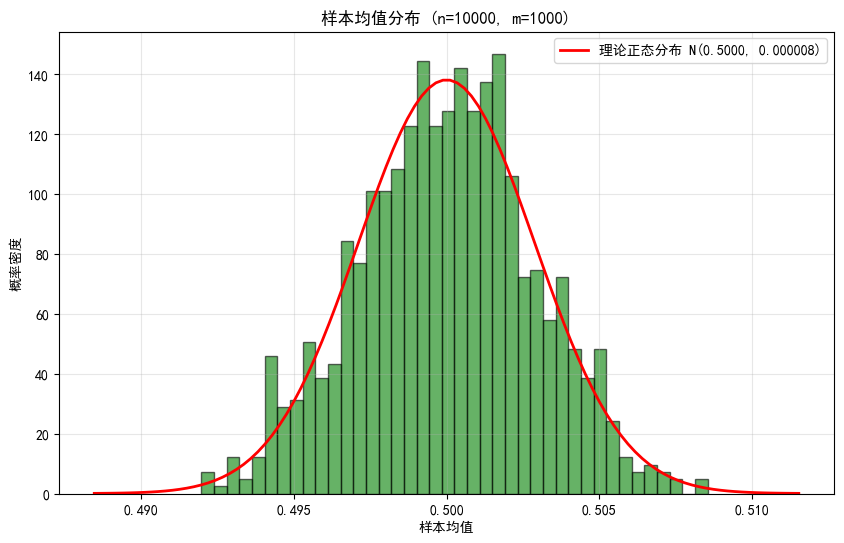


实际方差 (样本均值的方差): 0.00000831
理论方差 (1/(12n)): 0.00000833
相对误差: 0.2300%


In [5]:

# %% [markdown]
# ### 3.2 编程题：中心极限定理模拟

# %%
print("\n" + "="*50)
print("3.2 编程题：中心极限定理模拟")
print("="*50)

# 参数设置
n = 10000      # 每次抽取的样本数
m = 1000       # 重复次数
sample_means = np.zeros(m)

for i in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means[i] = np.mean(samples)

# 理论正态分布参数：均匀分布 U(0,1) 的均值=0.5，方差=1/12
mu_theory = 0.5
sigma_theory = np.sqrt(1/12 / n)  # 样本均值的标准差

# 绘制直方图并叠加理论正态曲线
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(sample_means, bins=40, density=True, alpha=0.6, color='g', edgecolor='black')
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
pdf = norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'理论正态分布 N({mu_theory:.4f}, {sigma_theory**2:.6f})')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'样本均值分布 (n={n}, m={m})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 计算实际方差
actual_variance = np.var(sample_means, ddof=0)  # 总体方差
theory_variance = sigma_theory**2
print(f"\n实际方差 (样本均值的方差): {actual_variance:.8f}")
print(f"理论方差 (1/(12n)): {theory_variance:.8f}")
print(f"相对误差: {abs(actual_variance - theory_variance)/theory_variance*100:.4f}%")


In [6]:

# %% [markdown]
# ## 4 导数、反向传播和复杂度

# %% [markdown]
# ### 4.1 理论计算题

# %%
print("\n" + "="*50)
print("4.1 理论计算题：导数")
print("="*50)

import sympy as sp
w1, w2 = sp.symbols('w1 w2')
x1, x2, y = 2, 1, 3  # 常数

# 定义函数 z = (w1*x1 + w2*x2 - y)^2
z = (w1*x1 + w2*x2 - y)**2

# 计算偏导数表达式
dz_dw1 = sp.diff(z, w1)
dz_dw2 = sp.diff(z, w2)
print("1. 偏导数表达式：")
print(f"   ∂z/∂w1 = {dz_dw1}")
print(f"   ∂z/∂w2 = {dz_dw2}")

# 代入 w1=0.5, w2=1 计算梯度值
grad_w1_val = dz_dw1.subs({w1:0.5, w2:1})
grad_w2_val = dz_dw2.subs({w1:0.5, w2:1})
print(f"\n2. 当 w1=0.5, w2=1 时：")
print(f"   ∂z/∂w1 = {grad_w1_val}")
print(f"   ∂z/∂w2 = {grad_w2_val}")


4.1 理论计算题：导数
1. 偏导数表达式：
   ∂z/∂w1 = 8*w1 + 4*w2 - 12
   ∂z/∂w2 = 4*w1 + 2*w2 - 6

2. 当 w1=0.5, w2=1 时：
   ∂z/∂w1 = -4.00000000000000
   ∂z/∂w2 = -2.00000000000000


In [7]:

# %% [markdown]
# ### 4.2 编程题：手动反向传播与自动微分验证

# %%
print("\n" + "="*50)
print("4.2 编程题：手动反向传播 vs torch.autograd")
print("="*50)

# 定义变量（使用 torch 以便自动微分）
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print(f"前向计算结果：")
print(f"  a = x * w1 = {x.item()} * {w1.item()} = {a.item()}")
print(f"  b = a + w2 = {a.item()} + {w2.item()} = {b.item()}")
print(f"  L = b^2 = {L.item()}")

# 手动计算梯度（链式法则）
# L = b^2  => dL/db = 2b
# b = a + w2 => db/da = 1, db/dw2 = 1
# a = x * w1 => da/dw1 = x, da/dx = w1
# 因此：
# dL/dw1 = dL/db * db/da * da/dw1 = 2b * 1 * x
# dL/dw2 = dL/db * db/dw2 = 2b * 1
b_val = b.item()
x_val = x.item()
grad_w1_manual = 2 * b_val * x_val
grad_w2_manual = 2 * b_val

print(f"\n手动计算梯度（链式法则）：")
print(f"  ∂L/∂w1 = 2 * b * x = 2 * {b_val} * {x_val} = {grad_w1_manual}")
print(f"  ∂L/∂w2 = 2 * b = 2 * {b_val} = {grad_w2_manual}")

# 自动微分
L.backward()
print(f"\n自动微分结果 (torch.autograd)：")
print(f"  w1.grad = {w1.grad.item()}")
print(f"  w2.grad = {w2.grad.item()}")

# 验证一致性
assert np.isclose(grad_w1_manual, w1.grad.item()), "w1 梯度不一致！"
assert np.isclose(grad_w2_manual, w2.grad.item()), "w2 梯度不一致！"
print("\n手动计算与自动微分结果一致 ✓")



4.2 编程题：手动反向传播 vs torch.autograd
前向计算结果：
  a = x * w1 = 2.0 * 1.5 = 3.0
  b = a + w2 = 3.0 + 0.5 = 3.5
  L = b^2 = 12.25

手动计算梯度（链式法则）：
  ∂L/∂w1 = 2 * b * x = 2 * 3.5 * 2.0 = 14.0
  ∂L/∂w2 = 2 * b = 2 * 3.5 = 7.0

自动微分结果 (torch.autograd)：
  w1.grad = 14.0
  w2.grad = 7.0

手动计算与自动微分结果一致 ✓


In [8]:

# %% [markdown]
# ## 5 线性方法、基础优化和 softmax 回归

# %% [markdown]
# ### 5.1 理论计算题：线性回归梯度推导

# %%
print("\n" + "="*50)
print("5.1 理论计算题：线性回归损失函数偏导数")
print("="*50)
print("推导过程：")
print("损失函数 L = (1/n) * Σ(y_i - (w x_i + b))^2")
print("对 w 求偏导：")
print("∂L/∂w = (1/n) * Σ 2*(y_i - (w x_i + b)) * (-x_i)")
print("       = -(2/n) * Σ x_i * (y_i - (w x_i + b))")
print("对 b 求偏导：")
print("∂L/∂b = (1/n) * Σ 2*(y_i - (w x_i + b)) * (-1)")
print("       = -(2/n) * Σ (y_i - (w x_i + b))")
print("\n(通常优化时使用梯度下降，负号会被吸收到更新公式中)")



5.1 理论计算题：线性回归损失函数偏导数
推导过程：
损失函数 L = (1/n) * Σ(y_i - (w x_i + b))^2
对 w 求偏导：
∂L/∂w = (1/n) * Σ 2*(y_i - (w x_i + b)) * (-x_i)
       = -(2/n) * Σ x_i * (y_i - (w x_i + b))
对 b 求偏导：
∂L/∂b = (1/n) * Σ 2*(y_i - (w x_i + b)) * (-1)
       = -(2/n) * Σ (y_i - (w x_i + b))

(通常优化时使用梯度下降，负号会被吸收到更新公式中)



5.2 编程题：Softmax 回归 (Digits 数据集)
Epoch  10/50, Loss: 0.4396
Epoch  20/50, Loss: 0.2945
Epoch  30/50, Loss: 0.2372
Epoch  40/50, Loss: 0.2051
Epoch  50/50, Loss: 0.1838

测试集准确率: 96.39%


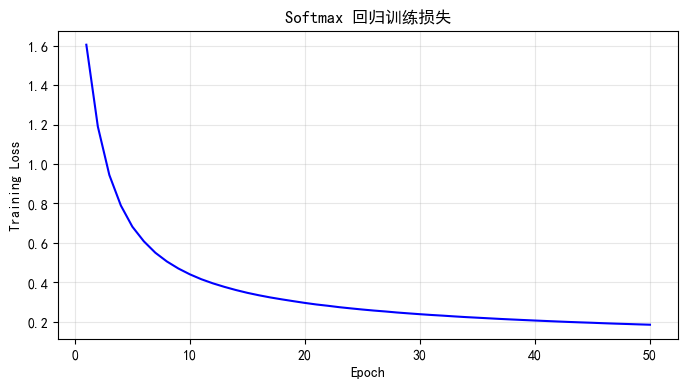

In [9]:

# %% [markdown]
# ### 5.2 编程题：从零实现 softmax 回归 (MNIST 子集)

# %%
print("\n" + "="*50)
print("5.2 编程题：Softmax 回归 (Digits 数据集)")
print("="*50)

# 加载数据
digits = load_digits()
X_all = digits.data / 16.0  # 简单归一化到 [0,1] 范围 (原始像素0-16)
y_all = digits.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# 超参数
num_features = X_train.shape[1]  # 64
num_classes = 10
batch_size = 32
learning_rate = 0.1
epochs = 50

# 将标签转换为 one-hot 编码
def to_one_hot(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train_oh = to_one_hot(y_train, num_classes)
y_test_oh = to_one_hot(y_test, num_classes)

# 初始化权重和偏置
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Softmax 函数
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(probs, y_onehot):
    n = probs.shape[0]
    loss = -np.sum(y_onehot * np.log(probs + 1e-8)) / n
    return loss

# 训练循环
num_samples = X_train.shape[0]
loss_history = []

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_oh[indices]
    
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = np.dot(X_batch, W) + b
        probs = softmax(logits)
        
        # 计算梯度
        error = probs - y_batch  # shape (batch_size, num_classes)
        grad_W = np.dot(X_batch.T, error) / batch_size
        grad_b = np.mean(error, axis=0, keepdims=True)
        
        # 参数更新
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    # 计算整个训练集损失
    train_logits = np.dot(X_train, W) + b
    train_probs = softmax(train_logits)
    train_loss = cross_entropy_loss(train_probs, y_train_oh)
    loss_history.append(train_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {train_loss:.4f}")

# 测试准确率
test_logits = np.dot(X_test, W) + b
test_probs = softmax(test_logits)
y_pred = np.argmax(test_probs, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {accuracy*100:.2f}%")

# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Softmax 回归训练损失')
plt.grid(alpha=0.3)
plt.show()


In [10]:

# %% [markdown]
# ## 6 最大似然估计和逻辑回归

# %% [markdown]
# ### 6.1 理论计算题：正态分布最大似然估计证明

# %%
print("\n" + "="*50)
print("6.1 理论计算题：正态分布 MLE 证明")
print("="*50)
print("1. 似然函数：")
print("   L(μ, σ²) = ∏_{i=1}^{n} (1/√(2πσ²)) * exp( -(x_i - μ)² / (2σ²) )")
print("   对数似然：")
print("   ℓ(μ, σ²) = -n/2 * ln(2π) - n/2 * ln(σ²) - 1/(2σ²) * Σ(x_i - μ)²")
print("\n2. 对 μ 求偏导并令为0：")
print("   ∂ℓ/∂μ = 1/σ² * Σ(x_i - μ) = 0  =>  Σx_i - nμ = 0  =>  μ̂ = (1/n) Σx_i")
print("\n3. 对 σ² 求偏导并令为0：")
print("   令 v = σ²，∂ℓ/∂v = -n/(2v) + 1/(2v²) * Σ(x_i - μ)² = 0")
print("   => -n v + Σ(x_i - μ)² = 0  =>  v̂ = (1/n) Σ(x_i - μ̂)²")
print("   即 σ̂² = (1/n) Σ(x_i - μ̂)²")
print("\n证明完成。")



6.1 理论计算题：正态分布 MLE 证明
1. 似然函数：
   L(μ, σ²) = ∏_{i=1}^{n} (1/√(2πσ²)) * exp( -(x_i - μ)² / (2σ²) )
   对数似然：
   ℓ(μ, σ²) = -n/2 * ln(2π) - n/2 * ln(σ²) - 1/(2σ²) * Σ(x_i - μ)²

2. 对 μ 求偏导并令为0：
   ∂ℓ/∂μ = 1/σ² * Σ(x_i - μ) = 0  =>  Σx_i - nμ = 0  =>  μ̂ = (1/n) Σx_i

3. 对 σ² 求偏导并令为0：
   令 v = σ²，∂ℓ/∂v = -n/(2v) + 1/(2v²) * Σ(x_i - μ)² = 0
   => -n v + Σ(x_i - μ)² = 0  =>  v̂ = (1/n) Σ(x_i - μ̂)²
   即 σ̂² = (1/n) Σ(x_i - μ̂)²

证明完成。



6.2 编程题：逻辑回归二分类
Iteration  200/1000, Loss: 0.0221
Iteration  400/1000, Loss: 0.0146
Iteration  600/1000, Loss: 0.0115
Iteration  800/1000, Loss: 0.0098
Iteration 1000/1000, Loss: 0.0087

测试集准确率: 100.00%


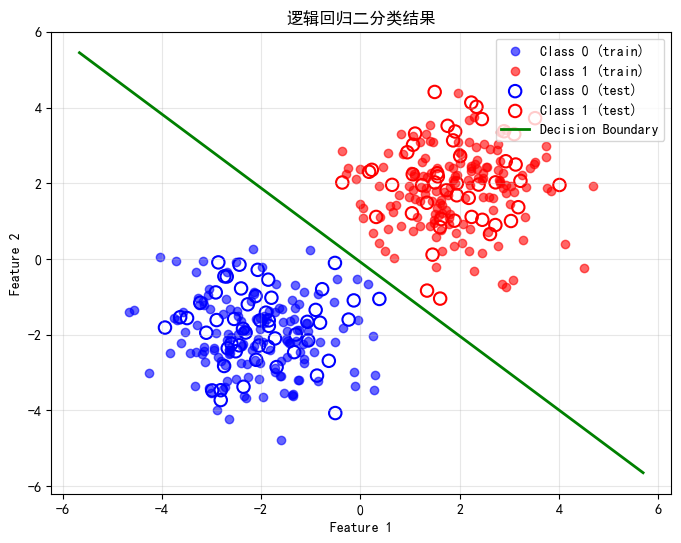

In [11]:

# %% [markdown]
# ### 6.2 编程题：二分类逻辑回归（从零实现）

# %%
print("\n" + "="*50)
print("6.2 编程题：逻辑回归二分类")
print("="*50)

# 生成线性可分数据
np.random.seed(0)
num_samples_per_class = 200
# 类别0：均值 [-2, -2]，协方差 [[1,0],[0,1]]
X0 = np.random.randn(num_samples_per_class, 2) + np.array([-2, -2])
# 类别1：均值 [2, 2]
X1 = np.random.randn(num_samples_per_class, 2) + np.array([2, 2])
X = np.vstack((X0, X1))
y = np.hstack((np.zeros(num_samples_per_class), np.ones(num_samples_per_class))).reshape(-1, 1)

# 划分训练集和测试集
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=100, random_state=42)

# Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 初始化参数
n_features = 2
W_lr = np.zeros((n_features, 1))
b_lr = 0.0
lr = 0.1
iterations = 1000
m = X_train_lr.shape[0]

losses = []
for i in range(iterations):
    # 前向
    z = np.dot(X_train_lr, W_lr) + b_lr
    y_hat = sigmoid(z)
    loss = binary_cross_entropy(y_train_lr, y_hat)
    losses.append(loss)
    
    # 梯度
    dz = y_hat - y_train_lr
    dW = (1/m) * np.dot(X_train_lr.T, dz)
    db = (1/m) * np.sum(dz)
    
    # 更新
    W_lr -= lr * dW
    b_lr -= lr * db
    
    if (i+1) % 200 == 0:
        print(f"Iteration {i+1:4d}/{iterations}, Loss: {loss:.4f}")

# 测试准确率
z_test = np.dot(X_test_lr, W_lr) + b_lr
y_pred_test = (sigmoid(z_test) >= 0.5).astype(int)
acc = accuracy_score(y_test_lr, y_pred_test)
print(f"\n测试集准确率: {acc*100:.2f}%")

# 绘制决策边界
plt.figure(figsize=(8, 6))
# 绘制训练点
plt.scatter(X_train_lr[y_train_lr.flatten()==0, 0], X_train_lr[y_train_lr.flatten()==0, 1], c='blue', label='Class 0 (train)', alpha=0.6)
plt.scatter(X_train_lr[y_train_lr.flatten()==1, 0], X_train_lr[y_train_lr.flatten()==1, 1], c='red', label='Class 1 (train)', alpha=0.6)
# 绘制测试点（用边缘颜色区分）
plt.scatter(X_test_lr[y_test_lr.flatten()==0, 0], X_test_lr[y_test_lr.flatten()==0, 1], 
            c='none', edgecolors='blue', linewidths=1.5, label='Class 0 (test)', s=80)
plt.scatter(X_test_lr[y_test_lr.flatten()==1, 0], X_test_lr[y_test_lr.flatten()==1, 1], 
            c='none', edgecolors='red', linewidths=1.5, label='Class 1 (test)', s=80)

# 决策边界直线: w0*x0 + w1*x1 + b = 0  => x1 = -(w0*x0 + b)/w1
x0_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x1_vals = -(W_lr[0,0] * x0_vals + b_lr) / W_lr[1,0]
plt.plot(x0_vals, x1_vals, 'g-', linewidth=2, label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('逻辑回归二分类结果')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
